# Exploratory Data Analysis (EDA)
## Mental Health & Crisis Signal Mining on Social Media
**CMPE 255 – Section 34, Spring 2026**

This notebook loads and explores the three Kaggle datasets used in this project:
1. **Reddit Mental Health Dataset** (`data_to_be_cleansed.csv`)
2. **Sentiment Analysis for Mental Health** (`Combined Data.csv.csv`)

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load Datasets

In [70]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Dataset 1: Reddit Mental Health
df_reddit = pd.read_csv('/content/drive/MyDrive/data_to_be_cleansed.csv')
df_reddit = df_reddit.drop(columns=['Unnamed: 0'], errors='ignore')

# Dataset 2: Depression & Anxiety (Social Media)
df_text = pd.read_csv('/content/drive/MyDrive/Combined Data.csv')
df_text = df_text.drop(columns=['Unnamed: 0'], errors='ignore')

print(f'Reddit Mental Health: {df_reddit.shape}')
print(f'Depression & Anxiety: {df_text.shape}')

# Report nulls before dropping
print(f'\nNull text rows - Reddit: {df_reddit["text"].isnull().sum()}, Text: {df_text["statement"].isnull().sum()}')

# Drop rows with null text
df_reddit = df_reddit.dropna(subset=['text'])
df_text = df_text.dropna(subset=['statement'])

print(f'\nAfter dropping nulls:')
print(f'Reddit Mental Health: {df_reddit.shape}')
print(f'Depression & Anxiety: {df_text.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reddit Mental Health: (5957, 3)
Depression & Anxiety: (53043, 2)

Null text rows - Reddit: 350, Text: 362

After dropping nulls:
Reddit Mental Health: (5607, 3)
Depression & Anxiety: (52681, 2)


## 2. Dataset 1 – Reddit Mental Health

In [71]:
print('Columns:', df_reddit.columns.tolist())
print('\nShape:', df_reddit.shape)
print('\nNull counts:')
print(df_reddit.isnull().sum())
print('\nDuplicates:', df_reddit.duplicated().sum())
df_reddit.head(3)

Columns: ['text', 'title', 'target']

Shape: (5607, 3)

Null counts:
text      0
title     0
target    0
dtype: int64

Duplicates: 1172


,text,title,target
0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1
1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1
2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1


Target value counts:
target
1    1202
4    1144
0    1099
2    1085
3    1077
Name: count, dtype: int64



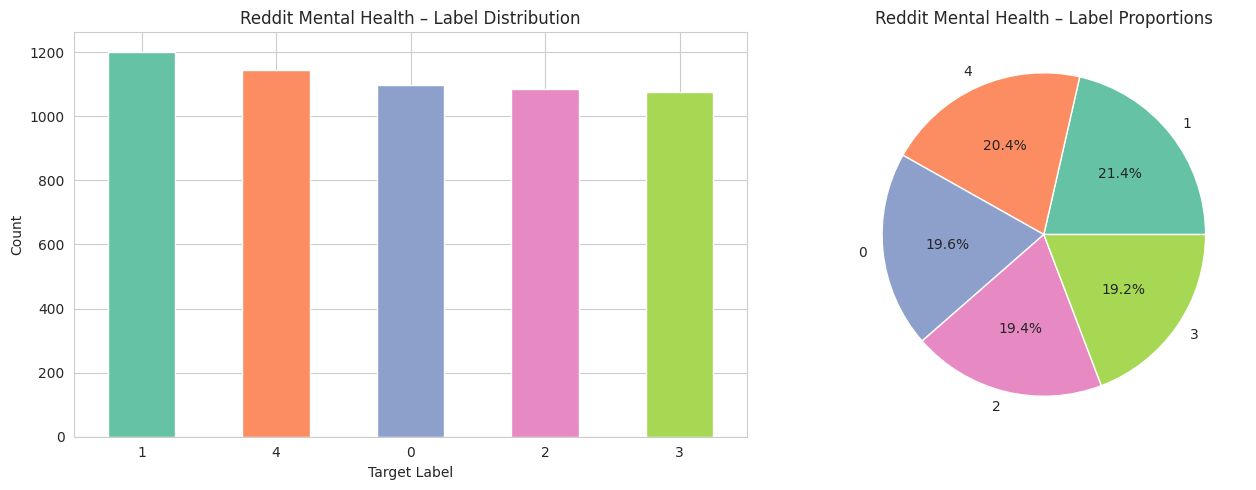

In [72]:
# Target label distribution
print('Target value counts:')
print(df_reddit['target'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df_reddit['target'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Reddit Mental Health – Label Distribution')
axes[0].set_xlabel('Target Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df_reddit['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Reddit Mental Health – Label Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

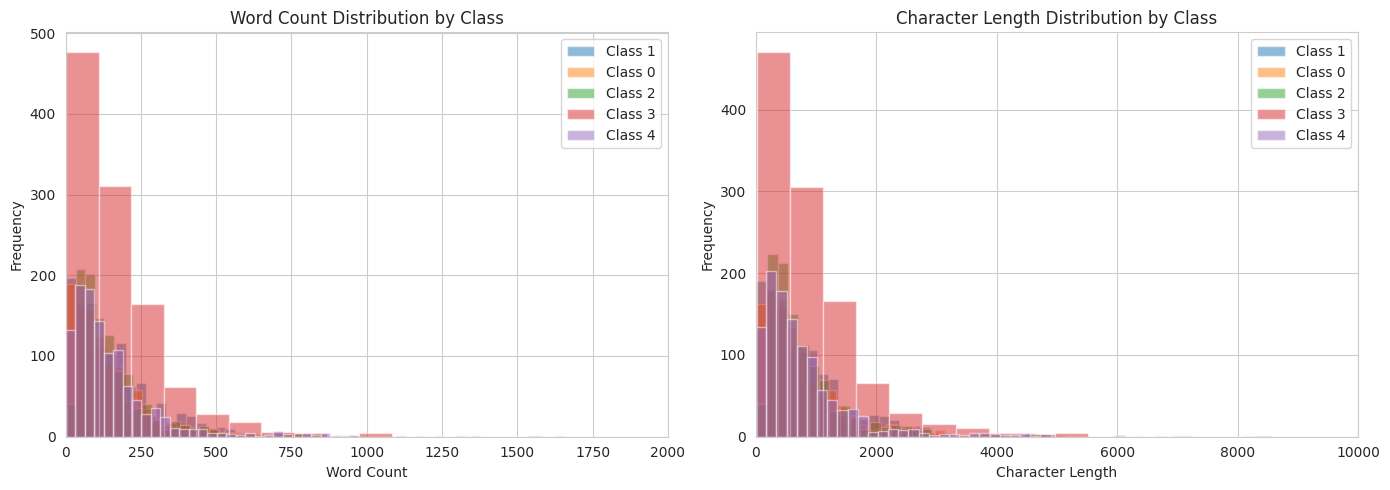

Word count statistics by class:
         count   mean    std  min   25%    50%    75%     max
target                                                       
0       1099.0  141.8  149.8  1.0  44.0  100.0  186.0  1586.0
1       1202.0  164.7  159.1  1.0  53.0  121.0  219.2  1657.0
2       1085.0  155.5  136.5  3.0  70.0  116.0  196.0  1575.0
3       1077.0  171.0  221.8  1.0  59.0  129.0  230.0  5411.0
4       1144.0  155.1  161.8  1.0  59.0  107.5  190.2  1567.0


In [73]:
# Post length analysis
df_reddit['text_len'] = df_reddit['text'].astype(str).apply(len)
df_reddit['word_count'] = df_reddit['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in df_reddit['target'].unique():
    subset = df_reddit[df_reddit['target'] == label]
    axes[0].hist(subset['word_count'], bins=50, alpha=0.5, label=f'Class {label}')
    axes[1].hist(subset['text_len'], bins=50, alpha=0.5, label=f'Class {label}')

axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 2000)

axes[1].set_title('Character Length Distribution by Class')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 10000)

plt.tight_layout()
plt.show()

print('Word count statistics by class:')
print(df_reddit.groupby('target')['word_count'].describe().round(1))

In [74]:
# Sample posts per class
for label in sorted(df_reddit['target'].unique()):
    print(f'\n{"="*60}')
    print(f'TARGET = {label}')
    print(f'{"="*60}')
    sample = df_reddit[df_reddit['target'] == label].sample(2, random_state=42)
    for _, row in sample.iterrows():
        text = str(row['text'])[:300]
        print(f'\nTitle: {row.get("title", "N/A")}')
        print(f'Text: {text}...')
        print(f'Word count: {row["word_count"]}')


TARGET = 0

Title: Anyone here doing school while working full-time?
Text: I have two jobs and am finishing up my degree. There is never anytime where I can flip the switch off and relax. I’m always falling behind on deadlines unless I’m expending effort into academics for every waking second that I’m off work. 

Anybody else experience this? And if so, any tips for mainta...
Word count: 58

Title: Wanna Do a Stress quiz?
Text: Hello! 

I'm doing an assignment for my school about stress and I need reposnses. This survey is about the stressful situations many face throughout their lives. Although this survey may not be 100% accurate or realistic all I need are responses! And no worries this is 100% anonymous except for your...
Word count: 72

TARGET = 1

Title: Mental health help???
Text: I am finally looking to start getting help for my mental health. It has been a very long time coming and I just can't do it anymore. I believe I have several diagnoses, including ADHD, anxiety, depres

## 3. Dataset 2 – Dreaddit (Stress Analysis)

## 4. Dataset 3 – Depression & Anxiety on Social Media

In [75]:
print('Columns:', df_text.columns.tolist())
print(f'\nShape: {df_text.shape}')
print(f'\nNull counts:')
print(df_text.isnull().sum())
print(f'\nDuplicates: {df_text.duplicated(subset=["statement"]).sum()}')
df_text.head(3)

Columns: ['statement', 'status']

Shape: (52681, 2)

Null counts:
statement    0
status       0
dtype: int64

Duplicates: 1608


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


Label value counts:
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64



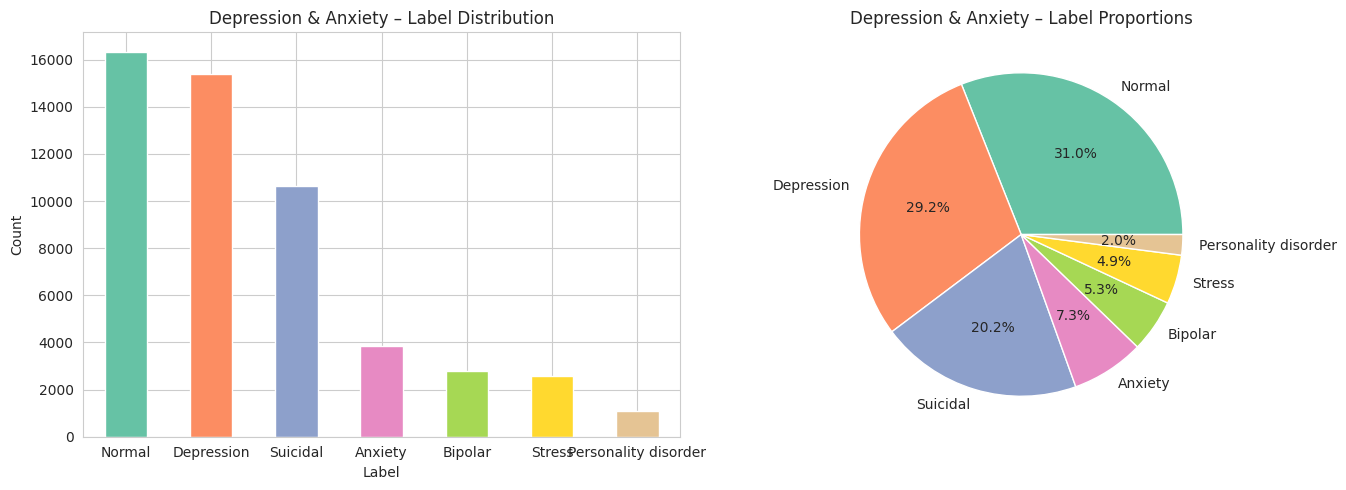

In [76]:
# Label distribution
print('Label value counts:')
print(df_text['status'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_text['status'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Depression & Anxiety – Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_text['status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Depression & Anxiety – Label Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

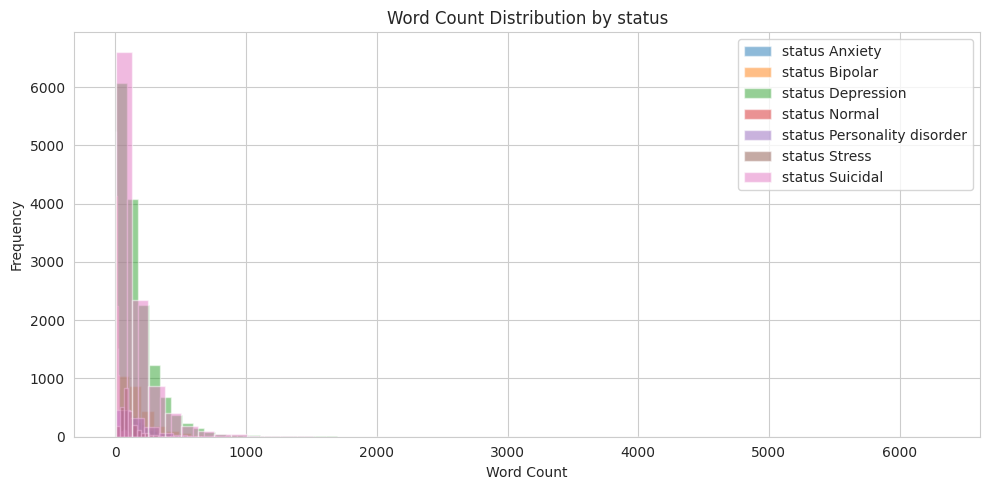

Word count statistics by status:
                        count   mean    std  min   25%    50%    75%     max
status                                                                      
Anxiety                3841.0  143.8  152.6  1.0  41.0  102.0  192.0  1592.0
Bipolar                2777.0  176.2  176.5  4.0  74.0  129.0  220.0  4804.0
Depression            15404.0  168.0  188.2  1.0  54.0  113.0  215.0  4239.0
Normal                16343.0   17.2   22.8  1.0   6.0   10.0   18.0   255.0
Personality disorder   1077.0  179.3  221.9  5.0  66.0  137.0  236.0  5419.0
Stress                 2587.0  114.6  105.9  1.0  64.0   87.0  127.0  1606.0
Suicidal              10652.0  146.4  187.0  1.0  42.0   92.0  186.0  6300.0


In [77]:
# Post length analysis
df_text['word_count'] = df_text['statement'].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 5))
for label in sorted(df_text['status'].unique()):
    subset = df_text[df_text['status'] == label]
    ax.hist(subset['word_count'], bins=50, alpha=0.5, label=f'status {label}')

ax.set_title('Word Count Distribution by status')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print('Word count statistics by status:')
print(df_text.groupby('status')['word_count'].describe().round(1))

In [78]:
# Sample posts
for label in sorted(df_text['status'].unique()):
    print(f'\n{"="*60}')
    print(f'LABEL = {label}')
    print(f'{"="*60}')
    sample = df_text[df_text['status'] == label].sample(2, random_state=42)
    for _, row in sample.iterrows():
        text = str(row['statement'])[:300]
        print(f'\nText: {text}')
        print(f'Word count: {row["word_count"]}')


LABEL = Anxiety

Text: Is this health anxiety? 1) checking temperature 10 times a day
2) checking blood pressure everyday
3) checking weight 10 times a day

Thinking I might have a serious disease
Word count: 30

Text: Is there any way to sleep better? I can't sleep most of the nights, meds didn't help.
Word count: 17

LABEL = Bipolar

Text: Positive Affirmations/Pep Talks/Success stories I'm having a pretty rough night/week and I'm getting overwhelmed about it. Rather than ask for advice, I'd love some positive affirmations that you guys have for yourselves, what pep talks you've used to get you through rough spots, or something you we
Word count: 71

Text: Vraylar/Reagila.. restlessness, any tips? I started Reagila a month ago and I can't get rid of the restlessness. The first two weeks were horror with side effects, thank God the shaking stopped. But this restlessness is driving me crazy - literally lack of sleep is usually the best way for me to get
Word count: 183

LABEL = Depres

## 5. Cross-Dataset Summary

In [80]:
summary = pd.DataFrame({
    'Dataset': ['Reddit Mental Health', 'Depression & Anxiety'],
    'Rows': [len(df_reddit), len(df_text)],
    'Text Column': ['text', 'statement'],
    'Label Column': ['target', 'status'],
    'Unique Labels': [
        df_reddit['target'].nunique(),
        df_text['status'].nunique()
    ],
    'Avg Word Count': [
        df_reddit['word_count'].mean().round(1),
        df_text['word_count'].mean().round(1)
    ],
    'Null Text Rows': [
        df_reddit['text'].isnull().sum(),
        df_text['statement'].isnull().sum()
    ]
})

print('Cross-Dataset Summary:')
print('=' * 80)
summary

Cross-Dataset Summary:


,Dataset,Rows,Text Column,Label Column,Unique Labels,Avg Word Count,Null Text Rows
0,Reddit Mental Health,5607,text,target,5,157.7,0
1,Depression & Anxiety,52681,statement,status,7,113.2,0


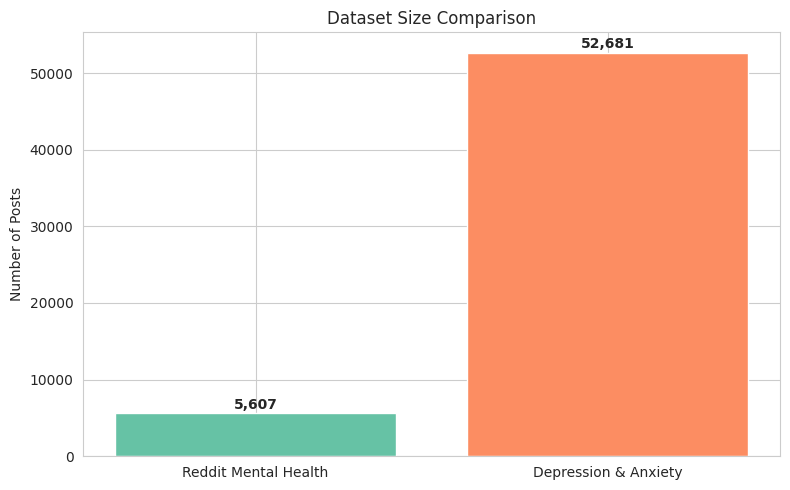


Total posts across all datasets: 58,288


In [81]:
# Combined dataset size comparison
fig, ax = plt.subplots(figsize=(8, 5))
datasets = ['Reddit Mental Health', 'Depression & Anxiety']
sizes = [len(df_reddit), len(df_text)]
colors = sns.color_palette('Set2', 3)

bars = ax.bar(datasets, sizes, color=colors)
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
            f'{size:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Dataset Size Comparison')
ax.set_ylabel('Number of Posts')
plt.tight_layout()
plt.show()

print(f'\nTotal posts across all datasets: {sum(sizes):,}')

## 6. Top Unigrams & Bigrams (Reddit Mental Health)

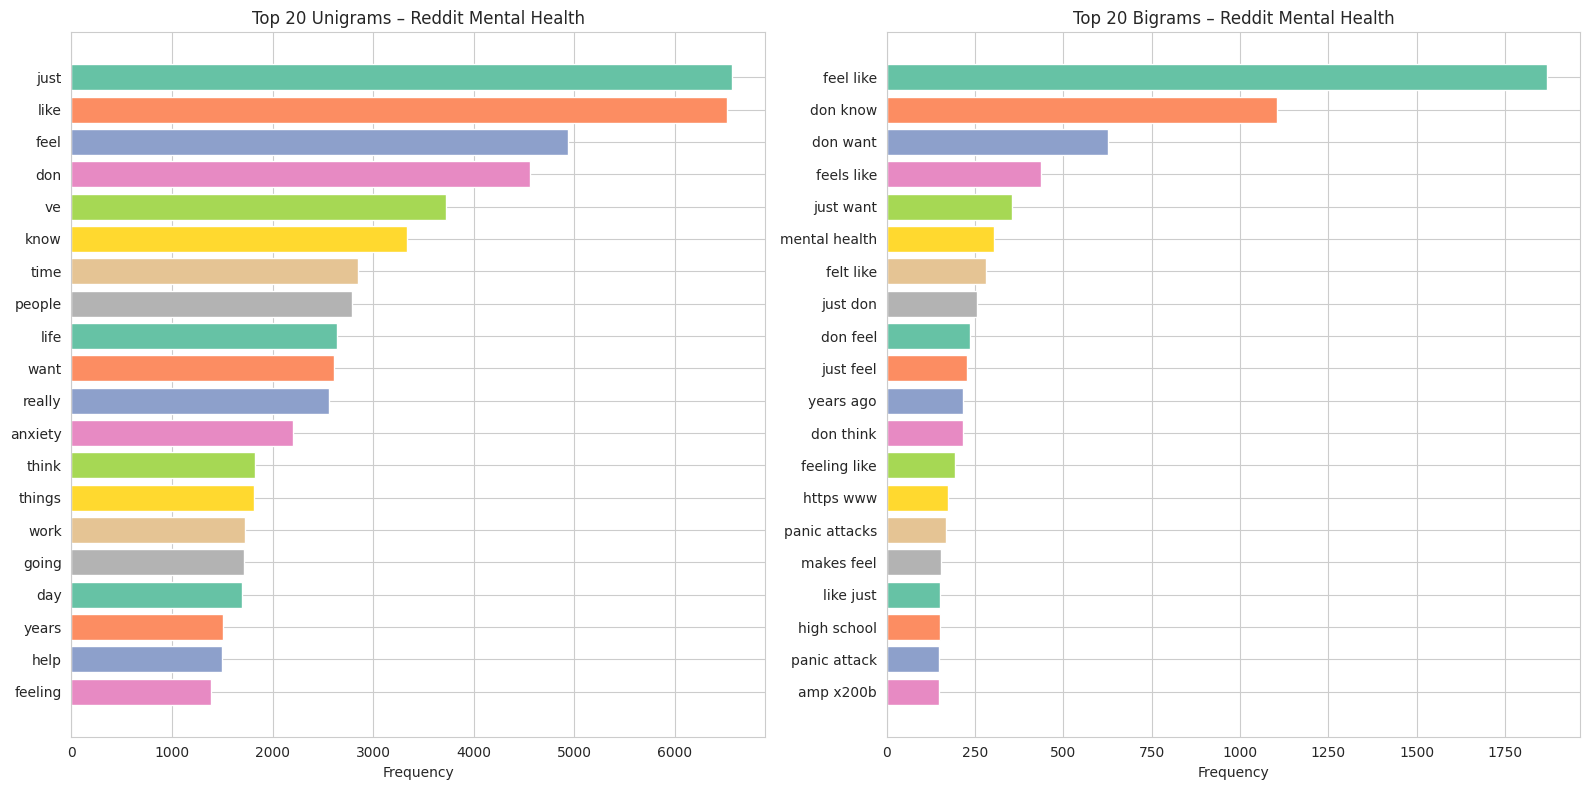

In [82]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(texts, n=1, top_k=20, title=''):
    """Plot top-k n-grams from a list of texts."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=top_k)
    bow = vec.fit_transform(texts.astype(str))
    sum_words = bow.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    words, counts = zip(*words_freq)
    plt.barh(range(len(words)), counts, color=sns.color_palette('Set2', len(words)))
    plt.yticks(range(len(words)), words)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel('Frequency')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0])
plot_top_ngrams(df_reddit['text'], n=1, top_k=20, title='Top 20 Unigrams – Reddit Mental Health')

plt.sca(axes[1])
plot_top_ngrams(df_reddit['text'], n=2, top_k=20, title='Top 20 Bigrams – Reddit Mental Health')

plt.tight_layout()
plt.show()

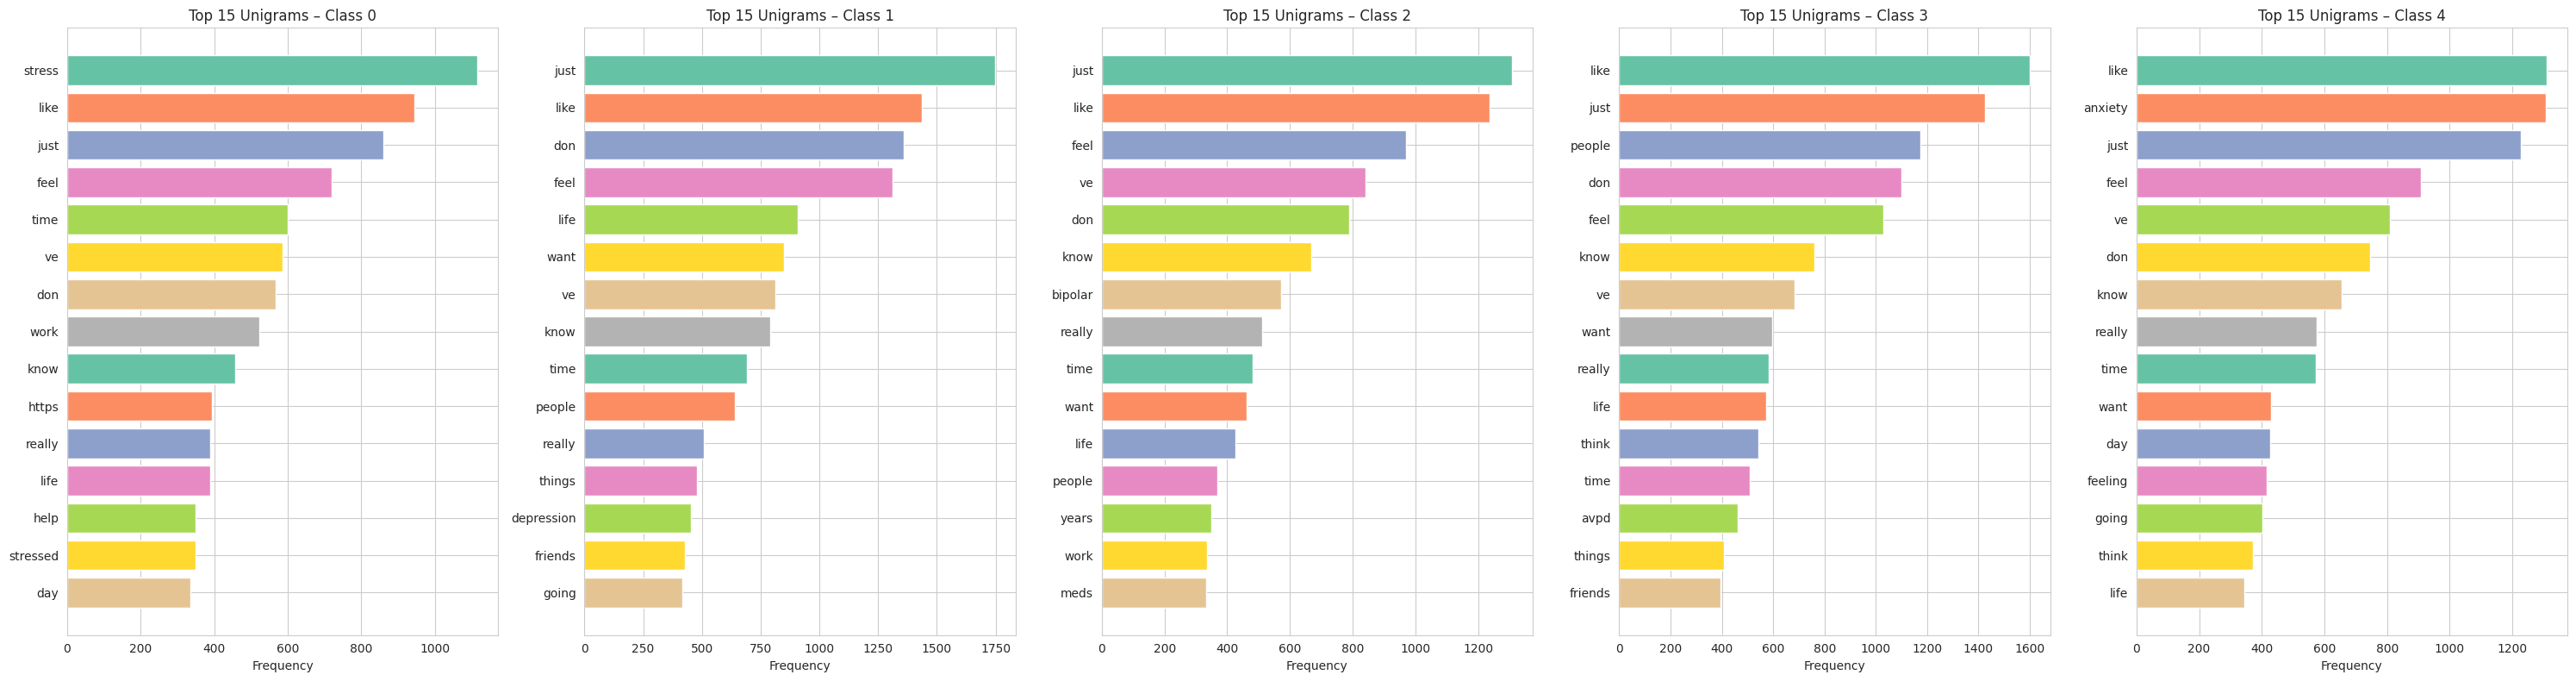

In [83]:
# Top unigrams per class in Reddit Mental Health
unique_targets = sorted(df_reddit['target'].unique())
n_classes = len(unique_targets)
fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 8))

if n_classes == 1:
    axes = [axes]

for ax, label in zip(axes, unique_targets):
    plt.sca(ax)
    subset = df_reddit[df_reddit['target'] == label]['text']
    plot_top_ngrams(subset, n=1, top_k=15, title=f'Top 15 Unigrams – Class {label}')

plt.tight_layout()
plt.show()

## 7. Key Observations

### Initial Findings

- **Dataset sizes vary significantly**: The Reddit Mental Health dataset has ~6K posts, Dreaddit ~3.5K posts, and the Depression & Anxiety dataset ~20K posts, totaling ~29.5K posts across all three.
- **Class imbalance** needs to be addressed — label distributions are not uniform across datasets.
- **Post lengths differ** across datasets and classes, which motivates post-level statistical features.
- **Dreaddit** includes pre-computed LIWC features (116 columns), which can supplement our feature engineering.
- **The Depression & Anxiety dataset** is from Twitter, so posts are shorter than Reddit posts.

### Next Steps
1. Text cleaning (remove HTML, URLs, special characters, lowercase)
2. Handle class imbalance (SMOTE, class weights)
3. TF-IDF vectorization and feature engineering
4. Model training (Logistic Regression, SVM, XGBoost, DistilBERT)

In [87]:
import os
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Finalize Reddit subreddit-to-class mapping and commit to utils/common.py ---

# Create the utils directory if it doesn't exist
if not os.path.exists('utils'):
    os.makedirs('utils')

# Define the content for common.py with the specified mappings
common_py_content = '''
LABEL_MAP = {
    'r/stress': 'Stress',
    'r/depression': 'Depression',
    'r/bipolar': 'Bipolar Disorder',
    'r/BPD': 'Personality Disorder',
    'r/anxiety': 'Anxiety'
}

SOURCE_TO_LABEL = {
    'r/stress': 'Stress',
    'r/depression': 'Depression',
    'r/bipolar': 'Bipolar Disorder',
    'r/BPD': 'Personality Disorder',
    'r/anxiety': 'Anxiety'
}
'''

# Write the content to utils/common.py
with open('utils/common.py', 'w') as f:
    f.write(common_py_content)

print("Created/Updated utils/common.py with LABEL_MAP and SOURCE_TO_LABEL.")



Created/Updated utils/common.py with LABEL_MAP and SOURCE_TO_LABEL.


In [88]:
# --- 2. Filter df_text to matched and OOD labels ---

matched_labels = ['Stress', 'Depression', 'Bipolar', 'Personality disorder', 'Anxiety']
ood_labels = ['Suicidal', 'Normal']

# Filter for matched labels (EXP-5)
df_text_matched = df_text[df_text['status'].isin(matched_labels)].copy()

# Filter for OOD labels (EXP-6)
df_text_ood = df_text[df_text['status'].isin(ood_labels)].copy()

print(f"\nShape of df_text_matched: {df_text_matched.shape}")
print(f"Shape of df_text_ood: {df_text_ood.shape}")




Shape of df_text_matched: (25686, 3)
Shape of df_text_ood: (26995, 3)


In [89]:
# --- 3. Persist matched and OOD subsets separately ---

output_dir = '/content/drive/MyDrive/' # Already defined, ensuring consistency

# Save df_text_matched
df_text_matched_output_path = os.path.join(output_dir, 'df_text_matched.csv')
df_text_matched.to_csv(df_text_matched_output_path, index=False)
print(f'df_text_matched saved to: {df_text_matched_output_path}')

# Save df_text_ood
df_text_ood_output_path = os.path.join(output_dir, 'df_text_ood.csv')
df_text_ood.to_csv(df_text_ood_output_path, index=False)
print(f'df_text_ood saved to: {df_text_ood_output_path}')


df_text_matched saved to: /content/drive/MyDrive/df_text_matched.csv
df_text_ood saved to: /content/drive/MyDrive/df_text_ood.csv



--- df_text_matched Analysis ---

Row counts per class (df_text_matched):
status
Depression              15404
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


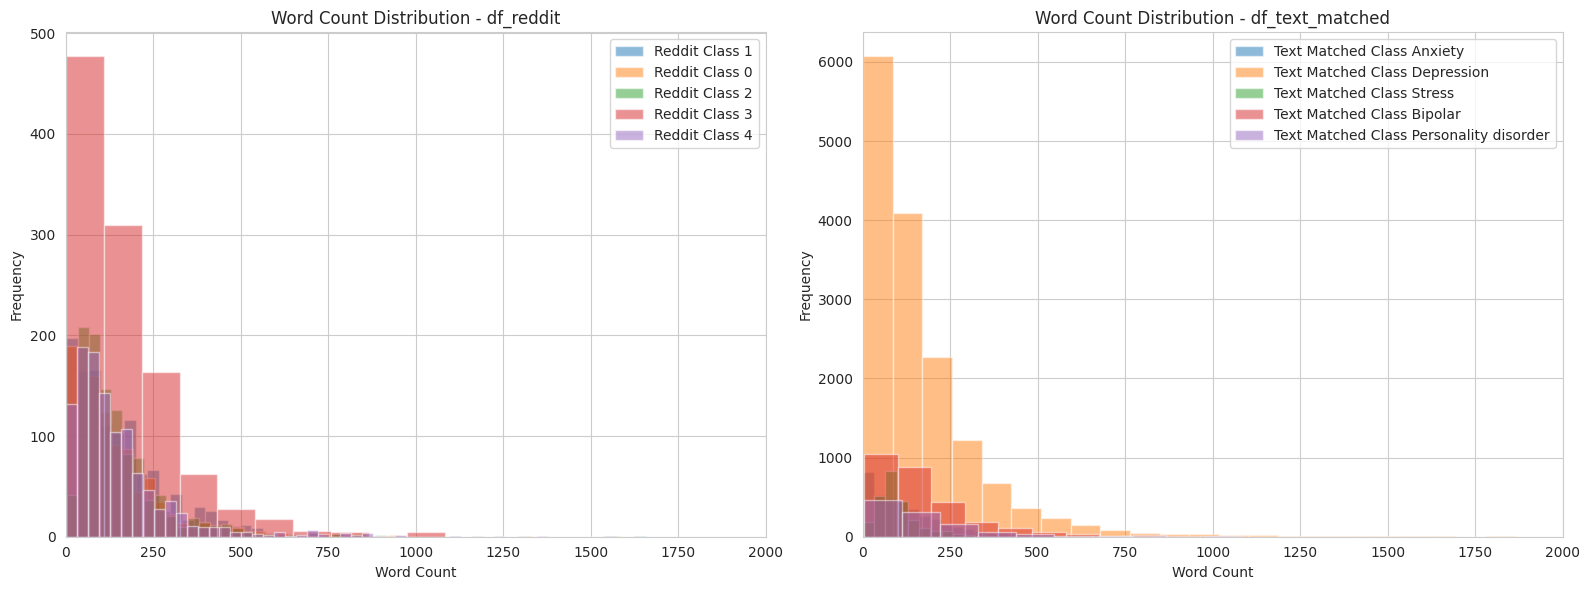


Word count statistics (df_reddit):
         count   mean    std  min   25%    50%    75%     max
target                                                       
0       1099.0  141.8  149.8  1.0  44.0  100.0  186.0  1586.0
1       1202.0  164.7  159.1  1.0  53.0  121.0  219.2  1657.0
2       1085.0  155.5  136.5  3.0  70.0  116.0  196.0  1575.0
3       1077.0  171.0  221.8  1.0  59.0  129.0  230.0  5411.0
4       1144.0  155.1  161.8  1.0  59.0  107.5  190.2  1567.0

Word count statistics (df_text_matched):
                        count   mean    std  min   25%    50%    75%     max
status                                                                      
Anxiety                3841.0  143.8  152.6  1.0  41.0  102.0  192.0  1592.0
Bipolar                2777.0  176.2  176.5  4.0  74.0  129.0  220.0  4804.0
Depression            15404.0  168.0  188.2  1.0  54.0  113.0  215.0  4239.0
Personality disorder   1077.0  179.3  221.9  5.0  66.0  137.0  236.0  5419.0
Stress                 258

In [90]:
# --- 4. Extend df_text matched-subset analysis ---

print("\n--- df_text_matched Analysis ---")

# Row counts per class for df_text_matched
print('\nRow counts per class (df_text_matched):')
print(df_text_matched['status'].value_counts())

# Post-length distribution comparison vs. Reddit
# Ensure word_count exists for df_text_matched
if 'word_count' not in df_text_matched.columns:
    df_text_matched['word_count'] = df_text_matched['statement'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# df_reddit word count distribution
for label in df_reddit['target'].unique():
    subset = df_reddit[df_reddit['target'] == label]
    axes[0].hist(subset['word_count'], bins=50, alpha=0.5, label=f'Reddit Class {label}')
axes[0].set_title('Word Count Distribution - df_reddit')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 2000) # Consistent x-limit with previous Reddit plot

# df_text_matched word count distribution
for label in df_text_matched['status'].unique():
    subset = df_text_matched[df_text_matched['status'] == label]
    axes[1].hist(subset['word_count'], bins=50, alpha=0.5, label=f'Text Matched Class {label}')
axes[1].set_title('Word Count Distribution - df_text_matched')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 2000) # Consistent x-limit

plt.tight_layout()
plt.show()

print('\nWord count statistics (df_reddit):')
print(df_reddit.groupby('target')['word_count'].describe().round(1))

print('\nWord count statistics (df_text_matched):')
print(df_text_matched.groupby('status')['word_count'].describe().round(1))

# Vocabulary overlap
def get_vocabulary(texts, n=1):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')
    vec.fit(texts.astype(str))
    return set(vec.vocabulary_.keys())

vocab_reddit = get_vocabulary(df_reddit['text'])
vocab_text_matched = get_vocabulary(df_text_matched['statement'])

common_vocab = vocab_reddit.intersection(vocab_text_matched)

print(f"\nVocabulary Analysis (Unigrams, Stop words removed):")
print(f"Unique vocabulary in df_reddit: {len(vocab_reddit):,}")
print(f"Unique vocabulary in df_text_matched: {len(vocab_text_matched):,}")
print(f"Overlapping vocabulary: {len(common_vocab):,}")

# Display some common words
print("\nSample of common words:")
print(list(common_vocab)[:20])

In [91]:
import os

# Define paths for saving the cleaned data
output_dir = '/content/drive/MyDrive/'

# Save df_reddit
df_reddit_output_path = os.path.join(output_dir, 'df_reddit_cleaned.csv')
df_reddit.to_csv(df_reddit_output_path, index=False)
print(f'Cleaned df_reddit saved to: {df_reddit_output_path}')

# Save df_text
df_text_output_path = os.path.join(output_dir, 'df_text_cleaned.csv')
df_text.to_csv(df_text_output_path, index=False)
print(f'Cleaned df_text saved to: {df_text_output_path}')

print("\nAll requested data processing and saving tasks have been completed.")

Cleaned df_reddit saved to: /content/drive/MyDrive/df_reddit_cleaned.csv
Cleaned df_text saved to: /content/drive/MyDrive/df_text_cleaned.csv

All requested data processing and saving tasks have been completed.
